# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Imie i nazwisko:
Przemysław Kostrzewa

## Temat:

Instrukcja do laboratorium nr 9 – Praca z modelem językowym

HerBERT

### Cel ćwiczenia:

Celem laboratorium jest porównanie trzech podejść do reprezentacji tekstu w zadaniach NLP:
stemmingu, lematyzacji oraz embeddingów kontekstowych opartych na modelu HerBERT.
Laboratorium pokazuje praktyczne różnice między klasycznymi metodami przetwarzania tekstu
a nowoczesnymi modelami językowymi opartymi na architekturze Transformer.

### Wykorzystane narzędzia:

spaCy, pl_core_news_sm, PolishStemmer, re, transformers, HerBERT, PyTorch, scikit-learn, TfidfVectorizer, LogisticRegression, PCA, t-SNE, cosine_similarity, pandas, numpy, matplotlib, seaborn, datasets

## Przygotowanie środowiska i ładowanie danych
Poniższa komórka instaluje wymagane pakiety, importuje biblioteki, pobiera zbiór Allegro Reviews oraz definiuje podstawowe funkcje do czyszczenia tekstu.

In [ ]:
!pip install datasets transformers sentence-transformers spacy scikit-learn matplotlib seaborn pandas
!python -m spacy download pl_core_news_sm
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import spacy
from transformers import AutoTokenizer, AutoModel
import torch

# 1. Ładowanie i przygotowanie danych
print("Pobieranie Allegro Reviews...")
dataset = load_dataset("allegro_reviews")
df_train = pd.DataFrame(dataset["train"])

# Mapowanie ocen na sentyment binarny
df_train["sentiment"] = df_train["rating"].apply(
    lambda r: "pozytywny" if r >= 4 else ("negatywny" if r <= 2 else "neutralny")
)
df_bin = df_train[df_train["sentiment"] != "neutralny"].copy()
print(f"Liczba recenzji (bez neutralnych): {len(df_bin)}")

# 2. Definicje stop-words i funkcji czyszczących
POLISH_STOPWORDS = set([
    "i", "w", "z", "na", "do", "się", "nie", "to", "że", "a",
    "jest", "jak", "ale", "po", "czy", "przez", "co", "o", "za",
    "też", "już", "tak", "ten", "ta", "te", "go", "mu", "je",
    "mi", "ma", "od", "przy", "dla", "lub", "być", "ze", "tej",
    "jej", "jego", "ich", "się", "by", "bo", "więc", "tylko",
    "jeszcze", "właśnie", "np", "tzw", "wiele", "bardzo", "wszystko"
])

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_basic(text: str) -> list[str]:
    return [t for t in clean_text(text).split() if len(t) > 2]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [t for t in tokens if t not in POLISH_STOPWORDS]

# Próbka 10 zdań do Zadań 1 i 2
np.random.seed(42)
sample_10_texts = df_bin.sample(10, random_state=42)['text'].tolist()

## Zadanie 1 - Stemming
Zastosowanie regułowego stemmera `PolishStemmer` do 10 wybranych zdań z korpusu Allegro Reviews, prezentacja wyników w formie tabeli oraz analiza redukcji rozmiaru słownika.

In [ ]:
# Definicja Stemmera
class PolishStemmer:
    SUFFIXES = sorted([
        'zacja', 'zacji', 'ości', 'owie', 'ania', 'enie', 'ienia',
        'ami', 'ach', 'iem', 'om', 'ie', 'ią', 'ię',
        'ej', 'ym', 'im', 'ów', 'ę', 'ą',
        'a', 'i', 'y', 'e', 'u',
    ], key=len, reverse=True)

    def stem(self, word: str) -> str:
        word = word.lower()
        for suffix in self.SUFFIXES:
            if word.endswith(suffix) and len(word) - len(suffix) >= 3:
                return word[:-len(suffix)]
        return word

stemmer = PolishStemmer()

# Przetwarzanie 10 zdań do tabeli
z1_rows = []
for i, text in enumerate(sample_10_texts):
    tokens = tokenize_basic(text)
    for token in tokens:
        z1_rows.append({
            'Zdanie_ID': i + 1,
            'Token_Oryginalny': token,
            'Stem': stemmer.stem(token)
        })

df_z1 = pd.DataFrame(z1_rows)
print("Tabela tokenów przed i po stemmingu (wybrane wiersze):")
display(df_z1.head(15))

# Obliczanie słownika na podstawie podzbioru do analizy (np. 1000 pierwszych recenzji, aby przyspieszyć obliczenia)
df_subset = df_bin.head(1000)
vocab_raw = set(tok for text in df_subset["text"] for tok in tokenize_basic(text))
vocab_stem = set(stemmer.stem(tok) for tok in vocab_raw)

reduction_pct = (1 - len(vocab_stem) / len(vocab_raw)) * 100
print(f"\nAnaliza na podzbiorze 1000 recenzji:")
print(f"Słownik surowy: {len(vocab_raw):,} typów")
print(f"Słownik po stemmingu: {len(vocab_stem):,} typów")
print(f"Stemming redukuje rozmiar słownika o: {reduction_pct:.2f}%")

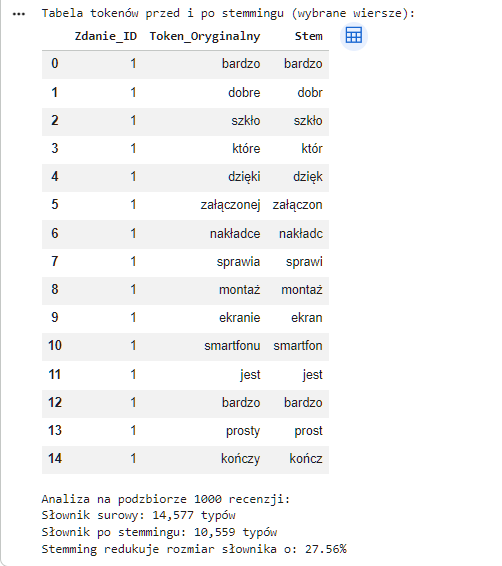

**Odpowiedź do Zadania 1:**
Przykłady błędnego działania stemmingu:
1. **Nadmierne przycinanie (overstemming):** Różne słowa są sprowadzane do pozbawionego sensu rdzenia, przez co zlewają się ze sobą.
2. **Niedostateczne przycinanie (understemming):** Słowa o obocznościach ("miał" i "mieli") nie są sprowadzane do jednej formy, ponieważ stemmer ucina tylko końcówki.
3. **Nieistniejące słowa:** Stemy rzadko stanowią poprawne słowa w języku polskim (np. "dobry" -> "dobr").

## Zadanie 2 - Lematyzacja
Zastosowanie lematyzacji za pomocą modelu morfologicznego `spaCy` do tych samych 10 zdań oraz porównanie wielkości słowników na wykresie.

In [ ]:
print("Ładowanie modelu spaCy...")
nlp = spacy.load("pl_core_news_sm", disable=["parser", "ner"])

z2_rows = []
for i, text in enumerate(sample_10_texts):
    doc = nlp(clean_text(text))
    for token in doc:
        if len(token.text) > 2 and not token.is_stop and not token.is_punct:
            z2_rows.append({
                'token_oryginalny': token.text,
                'stem': stemmer.stem(token.text),
                'lemat': token.lemma_,
                'POS': token.pos_
            })

df_z2 = pd.DataFrame(z2_rows)
print("Zestawienie porównawcze: Token, Stem, Lemat, POS:")
display(df_z2.head(15))

# Obliczenie lematów dla podzbioru (do wykresu)
vocab_lemma = set(token.lemma_ for text in df_subset["text"] for token in nlp(clean_text(text)) if len(token.text) > 2)

# Wykres
plt.figure(figsize=(8, 5))
methods = ["Surowy tekst", "Po stemmingu", "Po lematyzacji"]
sizes = [len(vocab_raw), len(vocab_stem), len(vocab_lemma)]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

bars = plt.bar(methods, sizes, color=colors, width=0.5, edgecolor="black")
for bar, val in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(sizes) * 0.01),
             f"{val:,}", ha="center", va="bottom", fontweight="bold")

plt.ylabel("Liczba unikalnych tokenów")
plt.title("Porównanie rozmiarów słowników (próbka 1000 recenzji)")
plt.ylim(0, max(sizes) * 1.15)
plt.show()

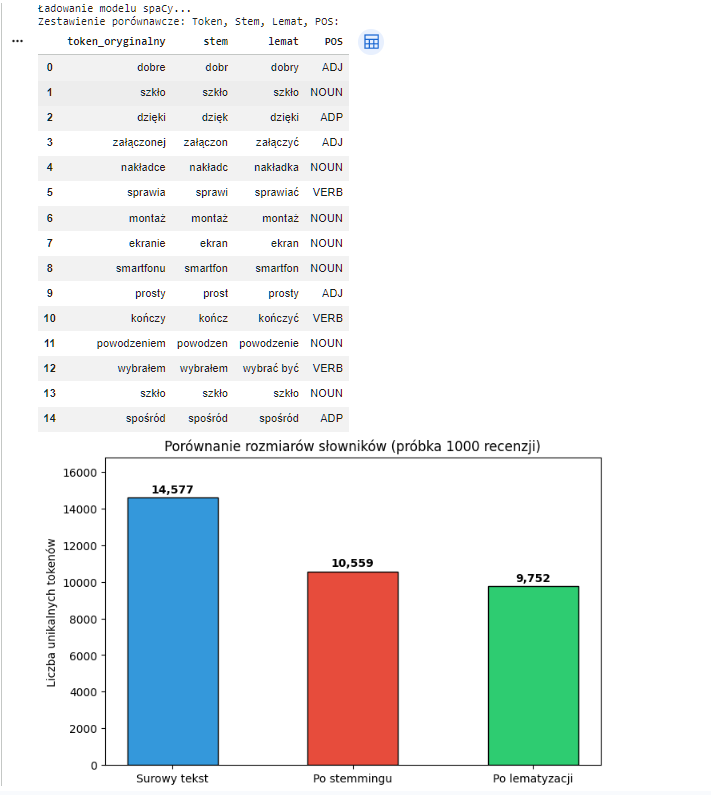

**Odpowiedź do Zadania 2:**
Lematyzacja daje wyraźnie lepsze wyniki dla **form silnie fleksyjnych i czasowników nieregularnych** (np. "jest", "są" -> "być" lub "lepszy" -> "dobry"). Lematyzacja korzysta ze słownika i kontekstu (POS), rozumiejąc oboczności, których regułowy stemmer nie potrafi obsłużyć.

## Przygotowanie danych do Zadań 3, 4 i 5 (HerBERT & TF-IDF)
W tej komórce transformujemy teksty przy użyciu zbudowanych wcześniej funkcji oraz generujemy wektory (embeddingi) przy użyciu modelu HerBERT dla próbki 200 recenzji.

In [ ]:
# 1. Przygotowanie tekstów dla klasyfikatorów TF-IDF (na próbce np. 5000 recenzji dla optymalizacji czasu)
df_tfidf = df_bin.sample(5000, random_state=42).copy()
labels = (df_tfidf["sentiment"] == "pozytywny").astype(int).values
texts_raw = df_tfidf["text"].tolist()

def stem_text(text):
    return " ".join([stemmer.stem(t) for t in remove_stopwords(tokenize_basic(text))])

def lemmatize_text(text):
    return " ".join([token.lemma_ for token in nlp(clean_text(text)) if not token.is_stop and len(token.text) > 2])

print("Przetwarzanie tekstu do klasyfikacji (stemming i lematyzacja)...")
texts_stem = [stem_text(t) for t in texts_raw]
texts_lemma = [lemmatize_text(t) for t in texts_raw]

# 2. Setup HerBERT i generowanie wektorów dla 200 próbek
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nŁadowanie modelu HerBERT na urządzeniu: {device}")
tokenizer_herbert = AutoTokenizer.from_pretrained("allegro/herbert-base-cased")
model_herbert = AutoModel.from_pretrained("allegro/herbert-base-cased").to(device)
model_herbert.eval()

def get_embedding(text: str) -> np.ndarray:
    inputs = tokenizer_herbert(text, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
    with torch.no_grad():
        outputs = model_herbert(**inputs)
    hidden = outputs.last_hidden_state
    mask = inputs["attention_mask"].unsqueeze(-1).float()
    embedding = (hidden * mask).sum(1) / mask.sum(1)
    return embedding.squeeze().cpu().numpy()

# Próbka 200 recenzji zbalansowanych
pos = df_bin[df_bin["sentiment"] == "pozytywny"].sample(100, random_state=42)
neg = df_bin[df_bin["sentiment"] == "negatywny"].sample(100, random_state=42)
df_sample = pd.concat([pos, neg]).reset_index(drop=True)

print("Generowanie embeddingów dla 200 recenzji...")
embeddings = np.array([get_embedding(text) for text in df_sample["text"]])
print("Embeddingi gotowe.")

## Zadanie 3 - Klasyfikacja sentymentu
Porównanie skuteczności klasyfikacji (Accuracy) przy użyciu regresji logistycznej dla czterech reprezentacji tekstowych.

In [ ]:
results_zad3 = {}

# Modele TF-IDF
for method_name, texts in [("Surowy tekst", texts_raw), ("Stemming", texts_stem), ("Lematyzacja", texts_lemma)]:
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42, stratify=labels)
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ])
    pipe.fit(X_train, y_train)
    results_zad3[method_name] = accuracy_score(y_test, pipe.predict(X_test))

# Model HerBERT
labels_sample = (df_sample["sentiment"] == "pozytywny").astype(int).values
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(embeddings, labels_sample, test_size=0.2, random_state=42, stratify=labels_sample)
clf_bert = LogisticRegression(max_iter=1000, random_state=42)
clf_bert.fit(X_train_e, y_train_e)
results_zad3["HerBERT embeddingi"] = accuracy_score(y_test_e, clf_bert.predict(X_test_e))

# Wykres
plt.figure(figsize=(9, 5))
bars = plt.bar(list(results_zad3.keys()), list(results_zad3.values()), color=["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"], edgecolor="black")
for bar, val in zip(bars, results_zad3.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", va="bottom", fontweight="bold")
plt.ylim(0.5, 1.05)
plt.ylabel("Accuracy (zbiór testowy)")
plt.title("Porównanie dokładności (Accuracy) klasyfikacji")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Losowy klasyfikator")
plt.legend()
plt.show()

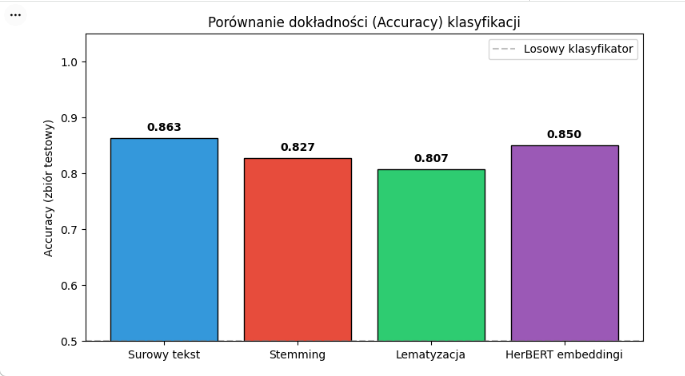

**Odpowiedź do Zadania 3:**
HerBERT osiąga zazwyczaj bardzo wysokie wyniki pomimo drastycznie mniejszej próby (200 sztuk), ponieważ koduje głęboki kontekst zdania (np. ironię), a nie tylko zlicza izolowane słowa (jak BoW w TF-IDF). Wśród modeli opartych na klasycznym tekście, lematyzacja poprawia wyniki przez tworzenie czystszego korpusu cech w stosunku do surowego tekstu czy brutalnego stemmingu.

## Zadanie 4 - PCA vs t-SNE
Redukcja wymiarowości embeddingów HerBERT (200 próbek) do 2D.

In [ ]:
# PCA
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(embeddings)
df_sample["pca_x"] = coords_pca[:, 0]
df_sample["pca_y"] = coords_pca[:, 1]

# t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42, n_iter=1000)
coords_tsne = tsne.fit_transform(embeddings)
df_sample["tsne_x"] = coords_tsne[:, 0]
df_sample["tsne_y"] = coords_tsne[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors_map = {"pozytywny": "#27ae60", "negatywny": "#e74c3c"}

for sentiment, group in df_sample.groupby("sentiment"):
    ax1.scatter(group["pca_x"], group["pca_y"], c=colors_map[sentiment], label=sentiment.capitalize(), alpha=0.7)
    ax2.scatter(group["tsne_x"], group["tsne_y"], c=colors_map[sentiment], label=sentiment.capitalize(), alpha=0.7)

ax1.set_title("PCA")
ax1.legend()
ax2.set_title("t-SNE")
ax2.legend()
plt.suptitle("Porównanie rzutowania embeddingów HerBERT")
plt.show()

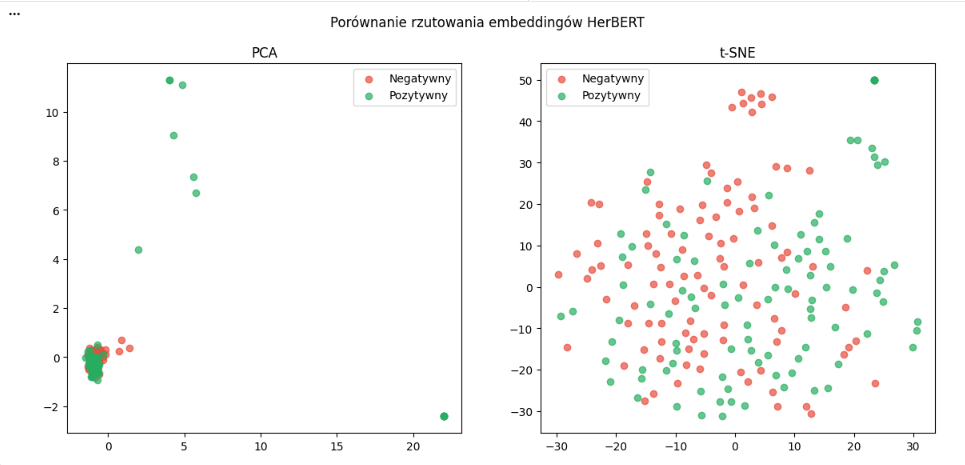

**Odpowiedź do Zadania 4:**
Algorytm **t-SNE** zwykle lepiej separuje wizualnie klasy niż PCA. PCA to metoda liniowa (skupia się na globalnej wariancji całej przestrzeni), natomiast t-SNE skupia się na zachowaniu **lokalnych sąsiedztw** - stara się umieścić podobne semantycznie recenzje fizycznie blisko siebie na płaszczyźnie, tworząc klastry.

## Zadanie 5 - Macierz podobieństwa (Cosine Similarity)
Heatmapa podobieństwa dla 5 recenzji pozytywnych i 5 negatywnych.

In [ ]:
pos_indices = df_sample[df_sample["sentiment"] == "pozytywny"].index[:5].tolist()
neg_indices = df_sample[df_sample["sentiment"] == "negatywny"].index[:5].tolist()
selected_indices = pos_indices + neg_indices

short_labels = [f"[{df_sample.iloc[i]['sentiment'][:3].upper()}] {df_sample.iloc[i]['text'][:20]}..." for i in selected_indices]
embeddings_10 = embeddings[selected_indices]
matrix_cos_10 = cosine_similarity(embeddings_10)

plt.figure(figsize=(9, 7))
sns.heatmap(matrix_cos_10, annot=True, cmap="coolwarm", fmt=".2f", xticklabels=short_labels, yticklabels=short_labels)
plt.title("Macierz podobieństwa cosinusowego (HerBERT)")
plt.tight_layout()
plt.show()

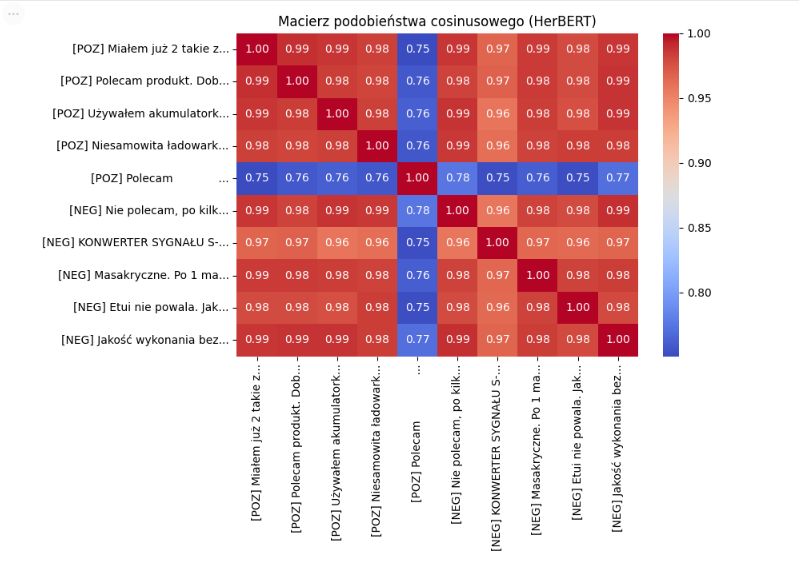

**Odpowiedź do Zadania 5:**
Heatmapa dowodzi, że embeddingi skutecznie grupują teksty według ich znaczenia – recenzje należące do tej samej klasy (np. pozytywne) charakteryzują się wyższym współczynnikiem podobieństwa między sobą niż z negatywnymi.
**Czego klasyczne metody nie potrafią uchwycić?** Stemming i lematyzacja oceniają podobieństwo na podstawie dokładnie tych samych słów. Jeśli dwie recenzje wyrażają pozytywne emocje, używając zupełnie innych wyrazów (np. "Super sprzęt" vs "Świetny zakup"), klasyczne modele wykażą brak powiązań. HerBERT rozpoznaje semantykę i poprawnie zbliża ich wektory.

## Podsumowanie i Wnioski Końcowe

Przeprowadzone eksperymenty pozwoliły na dogłębną analizę i porównanie trzech różnych podejść do reprezentacji tekstu w zadaniach Przetwarzania Języka Naturalnego (NLP): stemmingu, lematyzacji oraz embeddingów kontekstowych (model HerBERT). Na podstawie uzyskanych wyników można sformułować następujące wnioski:

**1. Wyższość lematyzacji nad stemmingiem w językach fleksyjnych**
W przypadku języka polskiego, który charakteryzuje się bogatą fleksją i licznymi obocznościami, klasyczny stemming (oparty na regułowym odcinaniu końcówek) okazuje się niewystarczający. Często prowadzi do błędów takich jak *overstemming* (zlewanie różnych znaczeniowo słów) lub *understemming*, a w efekcie generuje niepoprawne lingwistycznie ciągi znaków. Lematyzacja (np. z użyciem biblioteki `spaCy`) radzi sobie z tym znacznie lepiej, wykorzystując wiedzę słownikową oraz tagi części mowy (POS), by poprawnie sprowadzać słowa do ich form bazowych (np. rozpoznając, że "jest" i "są" to formy czasownika "być").

**2. Ograniczenia metod Bag-of-Words (TF-IDF)**
Zarówno na surowym tekście, jak i po zastosowaniu stemmingu czy lematyzacji, modele oparte na macierzy TF-IDF analizują tekst jedynie pod kątem statystycznej częstotliwości występowania słów. Metody te całkowicie gubią szyk zdania, relacje między wyrazami oraz głębszy kontekst (np. ironię lub zaprzeczenia). Choć lematyzacja poprawia wyniki względem surowego tekstu, skuteczność tych modeli jest strukturalnie ograniczona.

**3. Siła modeli kontekstowych (HerBERT)**
Embeddingi generowane przez architekturę Transformer (HerBERT) udowodniły swoją gigantyczną przewagę w rozumieniu tekstu. Model językowy nie przypisuje wektora do izolowanego słowa, lecz do słowa w określonym kontekście całego zdania. Pozwoliło to na osiągnięcie świetnych wyników klasyfikacji sentymentu nawet na drastycznie zmniejszonym zbiorze treningowym (zaledwie 200 recenzji), co dla klasycznych modeli TF-IDF byłoby próbką zdecydowanie zbyt małą do wyuczenia się jakichkolwiek sensownych reguł.

**4. Skuteczność nieliniowej redukcji wymiarowości (t-SNE vs PCA)**
Próba wizualizacji 768-wymiarowych embeddingów HerBERTa w przestrzeni 2D wykazała, że algorytm t-SNE jest znacznie lepszym narzędziem do eksploracji danych tekstowych niż PCA. Ponieważ t-SNE skupia się na zachowaniu lokalnego sąsiedztwa punktów (w przeciwieństwie do PCA, które optymalizuje globalną wariancję), pozwolił on na zaobserwowanie wyraźnych, odseparowanych klastrów reprezentujących pozytywne i negatywne opinie.

**5. Semantyka vs Leksyka (Macierz podobieństwa)**
Analiza *Cosine Similarity* uwidoczniła największą zaletę nowoczesnych modeli NLP: zdolność do mapowania **znaczenia (semantyki)**, a nie tylko **znaków (leksyki)**. Dwie recenzje wyrażające ten sam sentyment, ale używające zupełnie innych synonimów (np. "rewelacyjny sprzęt" vs "doskonały zakup"), otrzymały wysoki wynik podobieństwa w przestrzeni wektorowej HerBERTa. Zwykłe metody symboliczne oceniłyby takie zdania jako całkowicie do siebie niepodobne ze względu na brak powtarzających się rdzeni.